# Proyecto Final - Sistema de Recomendación Musical
## Redes Bayesianas + Machine Learning | CC3085 IA | UVG 2026
---

## 1. Configuración e Imports

In [1]:
# Instalar dependencias si es necesario:
# !pip install pandas numpy matplotlib seaborn scikit-learn pgmpy ipywidgets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Carga y Limpieza del Dataset

In [2]:
df = pd.read_csv('dataset.csv', index_col=0).dropna()

SELECTED_GENRES = ['reggaeton', 'latin', 'pop', 'rock', 'hip-hop',
                   'r-n-b', 'electronic', 'jazz', 'classical', 'metal']

df_sel = df[df['track_genre'].isin(SELECTED_GENRES)].copy()

print(f'Dataset total:        {df.shape[0]:,} canciones | {df["track_genre"].nunique()} géneros')
print(f'Géneros seleccionados: {df_sel.shape[0]:,} canciones | {len(SELECTED_GENRES)} géneros')
print(f'Balanceo por género:')
print(df_sel['track_genre'].value_counts().to_string())

Dataset total:        113,999 canciones | 114 géneros
Géneros seleccionados: 10,000 canciones | 10 géneros
Balanceo por género:
track_genre
classical     1000
electronic    1000
hip-hop       1000
jazz          1000
latin         1000
metal         1000
pop           1000
r-n-b         1000
reggaeton     1000
rock          1000


## 3. Análisis Exploratorio (EDA)

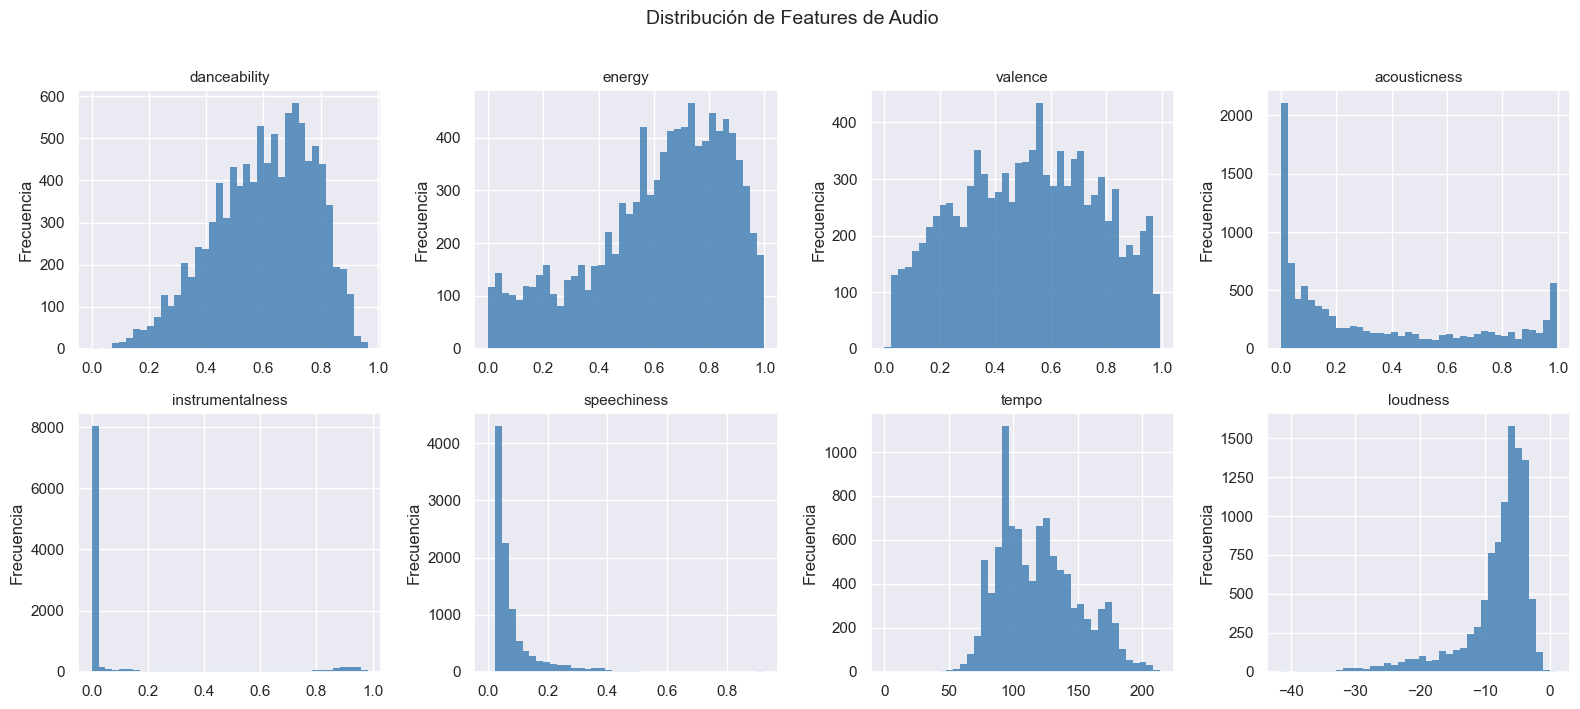

In [3]:
# ── Distribución de features de audio
AUDIO_FEATURES = ['danceability','energy','valence','acousticness',
                  'instrumentalness','speechiness','tempo','loudness']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, feat in enumerate(AUDIO_FEATURES):
    ax = axes[i // 4][i % 4]
    df_sel[feat].hist(bins=40, ax=ax, color='steelblue', alpha=0.85, edgecolor='none')
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribución de Features de Audio', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

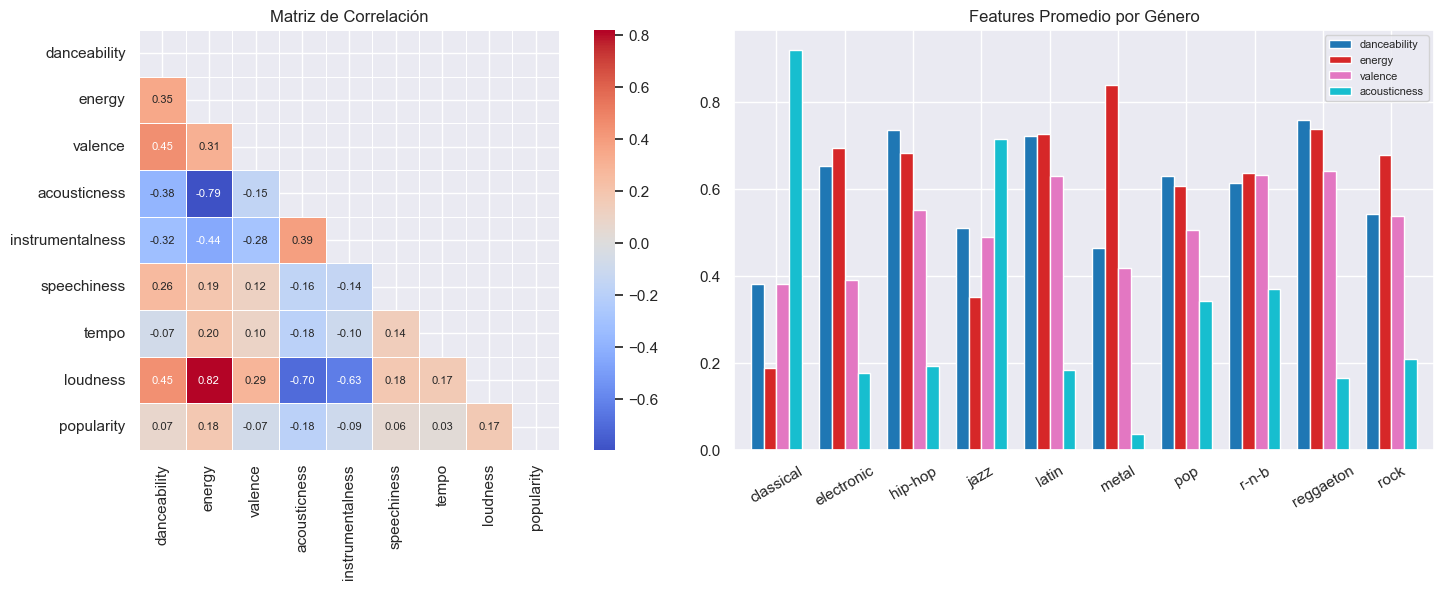

In [4]:
# ── Correlación con popularidad
numeric_cols = AUDIO_FEATURES + ['popularity']
corr = df_sel[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Matriz de Correlación')

# Perfil por género — danceability, energy, valence
key = ['danceability', 'energy', 'valence', 'acousticness']
genre_means = df_sel.groupby('track_genre')[key].mean()
genre_means.plot(kind='bar', ax=axes[1], colormap='tab10', width=0.75)
axes[1].set_title('Features Promedio por Género')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

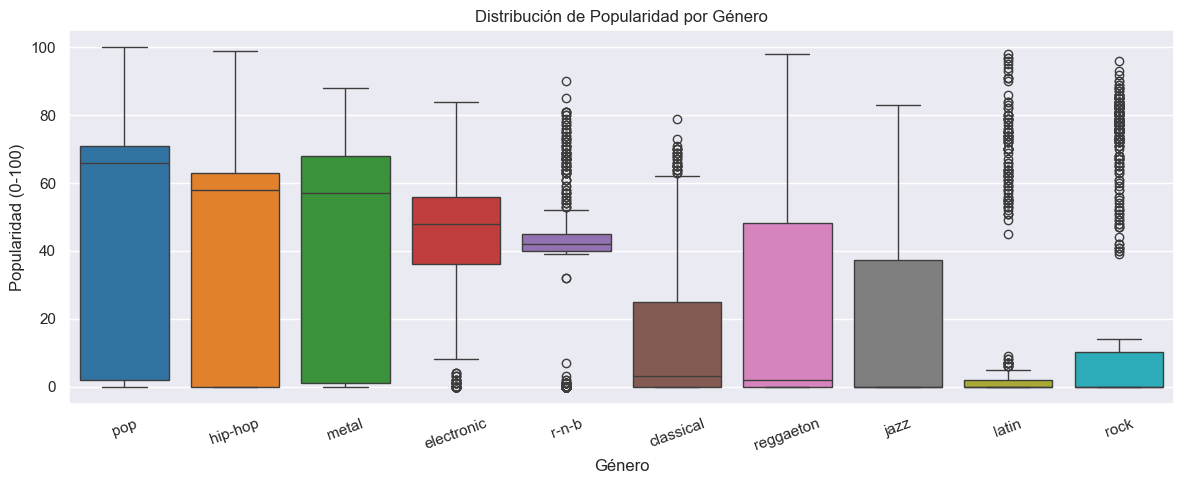

In [5]:
# ── Popularidad por género
fig, ax = plt.subplots(figsize=(12, 5))
genre_order = df_sel.groupby('track_genre')['popularity'].median().sort_values(ascending=False).index
sns.boxplot(data=df_sel, x='track_genre', y='popularity', order=genre_order, palette='tab10', ax=ax)
ax.set_title('Distribución de Popularidad por Género')
ax.set_xlabel('Género')
ax.set_ylabel('Popularidad (0-100)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

In [6]:
# ── Para modelos ML (normalización)
ML_FEATURES = ['danceability','energy','loudness','speechiness',
               'acousticness','instrumentalness','liveness','valence','tempo']

X = df_sel[ML_FEATURES]
y = df_sel['track_genre']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# ── Para Red Bayesiana (discretización por quantiles)
def discretize_df(data):
    d = data.copy()
    for col in ['energy', 'danceability', 'valence', 'acousticness']:
        d[col + '_d'] = pd.qcut(d[col], q=3, labels=['bajo','medio','alto'],
                                 duplicates='drop').astype(str)
    d['popularity_d'] = pd.cut(d['popularity'], bins=[0,30,60,100],
                                labels=['bajo','medio','alto']).astype(str)
    return d

df_disc = discretize_df(df_sel)
BN_COLS = ['track_genre','energy_d','danceability_d','valence_d','acousticness_d','popularity_d']
df_bn = df_disc[BN_COLS].rename(columns={'track_genre':'genre'})

print('\nDistribución de popularity_d:')
print(df_disc['popularity_d'].value_counts())

Train: (8000, 9) | Test: (2000, 9)

Distribución de popularity_d:
popularity_d
medio    2480
alto     2291
bajo     1749
Name: count, dtype: int64


## 5. Modelos de Machine Learning

Se entrenan tres clasificadores para predecir el **género** de una canción. El género es la variable central del perfil de preferencias del usuario.

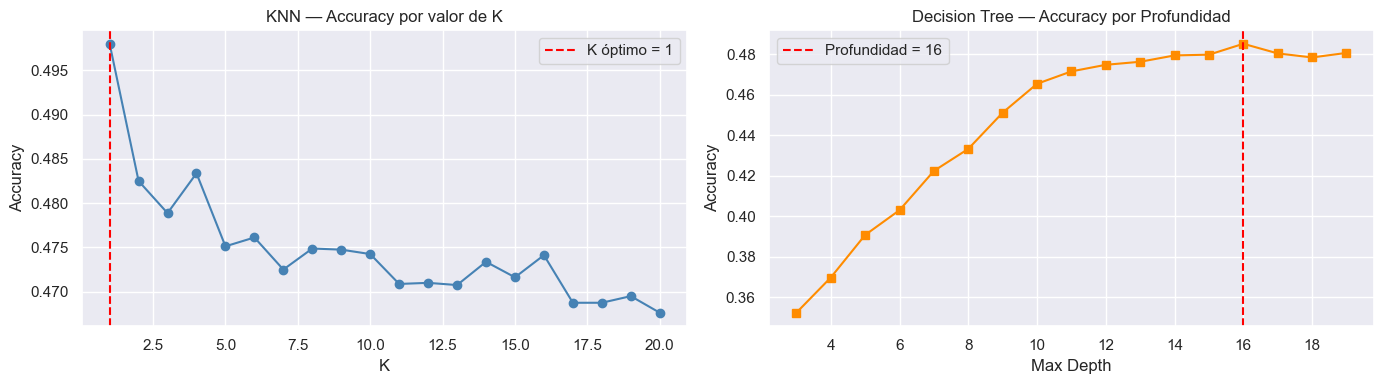

KNN K óptimo: 1 | DT profundidad óptima: 16


In [7]:
# ── KNN — búsqueda del K óptimo
k_values = range(1, 21)
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_train, y_train, cv=5).mean() for k in k_values]
best_k = list(k_values)[np.argmax(k_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(k_values, k_scores, marker='o', color='steelblue')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'K óptimo = {best_k}')
axes[0].set_title('KNN — Accuracy por valor de K')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

# ── Decision Tree — búsqueda de profundidad óptima
depths = range(3, 20)
dt_scores = [cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                              X_train, y_train, cv=5).mean() for d in depths]
best_depth = list(depths)[np.argmax(dt_scores)]

axes[1].plot(depths, dt_scores, marker='s', color='darkorange')
axes[1].axvline(best_depth, color='red', linestyle='--', label=f'Profundidad = {best_depth}')
axes[1].set_title('Decision Tree — Accuracy por Profundidad')
axes[1].set_xlabel('Max Depth'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'KNN K óptimo: {best_k} | DT profundidad óptima: {best_depth}')

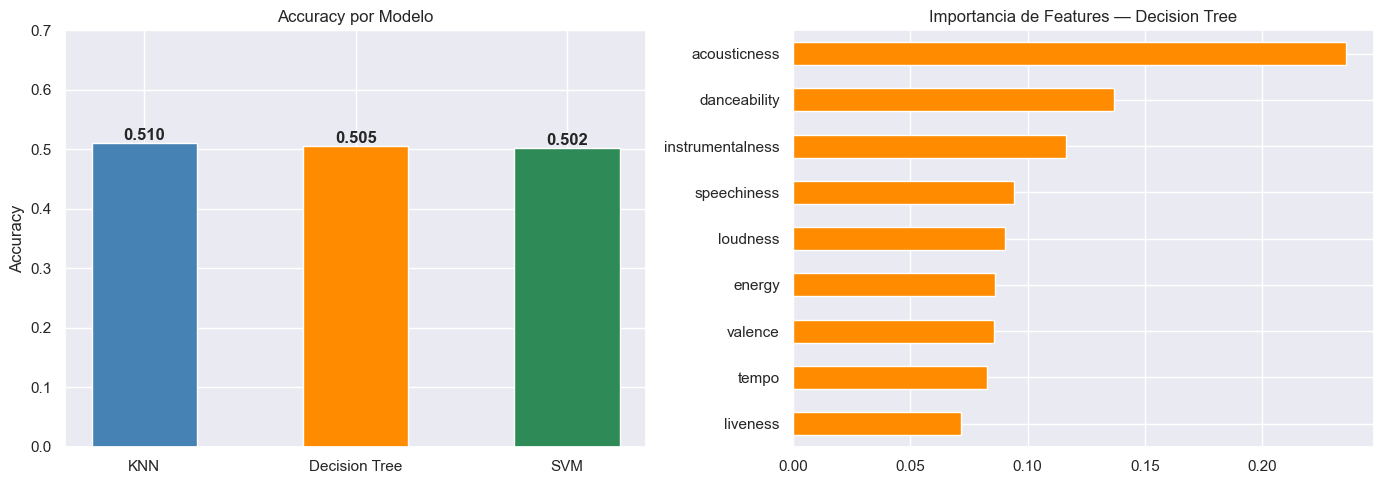


=== Accuracy final ===
  KNN                  0.5100
  Decision Tree        0.5055
  SVM                  0.5025


In [8]:
# ── Entrenar modelos finales
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# ── Comparación de accuracy
results = {
    'KNN': accuracy_score(y_test, y_pred_knn),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'SVM': accuracy_score(y_test, y_pred_svm),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de accuracy
colors_cmp = ['steelblue', 'darkorange', 'seagreen']
bars = axes[0].bar(results.keys(), results.values(), color=colors_cmp, edgecolor='white', width=0.5)
for bar, val in zip(bars, results.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 0.7); axes[0].set_title('Accuracy por Modelo'); axes[0].set_ylabel('Accuracy')

# Importancia de features (DT)
importances = pd.Series(dt_model.feature_importances_, index=ML_FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Importancia de Features — Decision Tree')

plt.tight_layout(); plt.show()

print('\n=== Accuracy final ===')
for m, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'  {m:<20} {acc:.4f}')

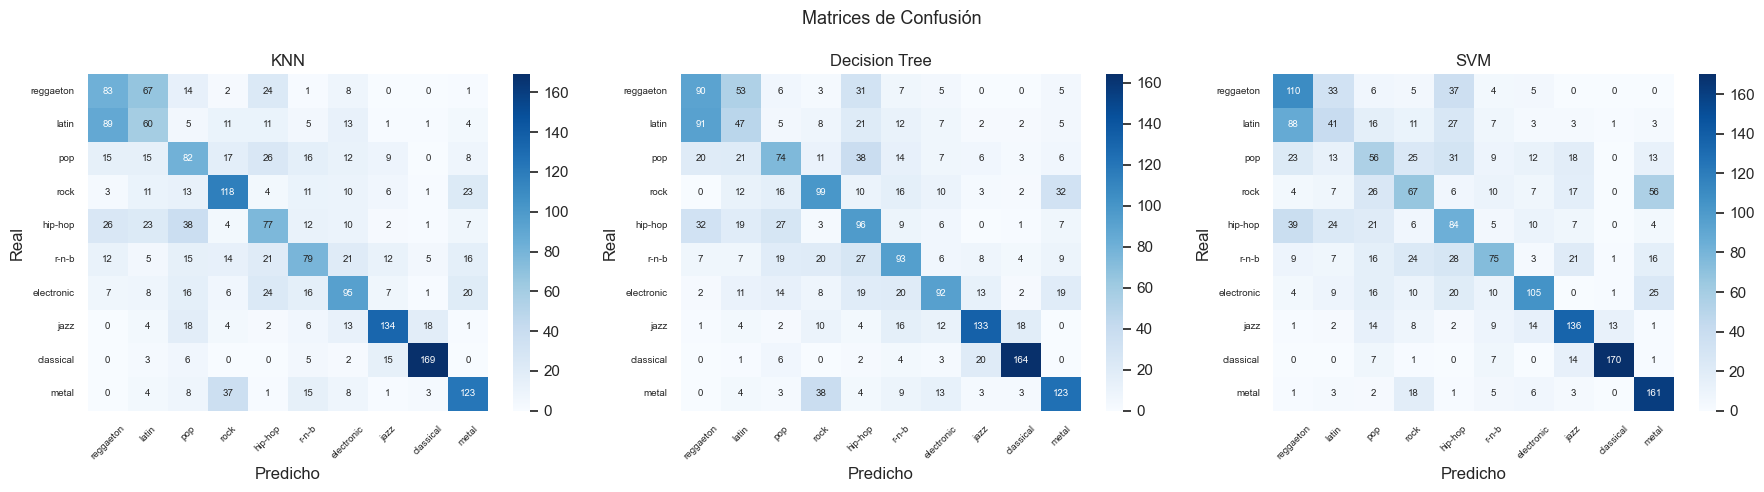

In [9]:
# ── Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, [('KNN', y_pred_knn), ('Decision Tree', y_pred_dt), ('SVM', y_pred_svm)]):
    cm = confusion_matrix(y_test, preds, labels=SELECTED_GENRES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=SELECTED_GENRES, yticklabels=SELECTED_GENRES, ax=ax, annot_kws={'size': 7})
    ax.set_title(f'{name}'); ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.suptitle('Matrices de Confusión', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Red Bayesiana

Estructura definida por conocimiento del dominio: el género determina el perfil de features, y las features influyen conjuntamente en la popularidad.

In [10]:
# ── Definir y entrenar la Red Bayesiana
BN_STRUCTURE = [
    ('genre', 'energy_d'),
    ('genre', 'danceability_d'),
    ('genre', 'valence_d'),
    ('genre', 'acousticness_d'),
    ('energy_d', 'popularity_d'),
    ('danceability_d', 'popularity_d'),
    ('valence_d', 'popularity_d'),
]

model_bn = DiscreteBayesianNetwork(BN_STRUCTURE)
model_bn.fit(df_bn, estimator=MaximumLikelihoodEstimator)
print('Red Bayesiana entrenada')
print(f'Nodos: {list(model_bn.nodes())}')
print(f'Es modelo válido: {model_bn.check_model()}')

Red Bayesiana entrenada
Nodos: ['genre', 'energy_d', 'danceability_d', 'valence_d', 'acousticness_d', 'popularity_d']
Es modelo válido: True


In [11]:
# ── Inferencia probabilística
infer = VariableElimination(model_bn)

def query_popularity(genre, energy=None, danceability=None, valence=None):
    evidence = {'genre': genre}
    if energy: evidence['energy_d'] = energy
    if danceability: evidence['danceability_d'] = danceability
    if valence: evidence['valence_d'] = valence

    result = infer.query(['popularity_d'], evidence=evidence)
    probs = dict(zip(result.state_names['popularity_d'], result.values))
    print(f'Evidencia: {evidence}')
    print(f'P(popularity | evidencia):')
    for k, v in sorted(probs.items(), key=lambda x: x[1], reverse=True):
        bar = '█' * int(v * 30)
        print(f'  {k:<8} {v:.4f}  {bar}')
    print()
    return probs

q1 = query_popularity('reggaeton', energy='alto', danceability='alto')
q2 = query_popularity('classical', energy='bajo')
q3 = query_popularity('metal', energy='alto', valence='bajo')

Evidencia: {'genre': 'reggaeton', 'energy_d': 'alto', 'danceability_d': 'alto'}
P(popularity | evidencia):
  medio    0.3413  ██████████
  bajo     0.3308  █████████
  alto     0.3279  █████████

Evidencia: {'genre': 'classical', 'energy_d': 'bajo'}
P(popularity | evidencia):
  bajo     0.4306  ████████████
  medio    0.3224  █████████
  alto     0.2470  ███████

Evidencia: {'genre': 'metal', 'energy_d': 'alto', 'valence_d': 'bajo'}
P(popularity | evidencia):
  alto     0.4325  ████████████
  medio    0.4195  ████████████
  bajo     0.1480  ████



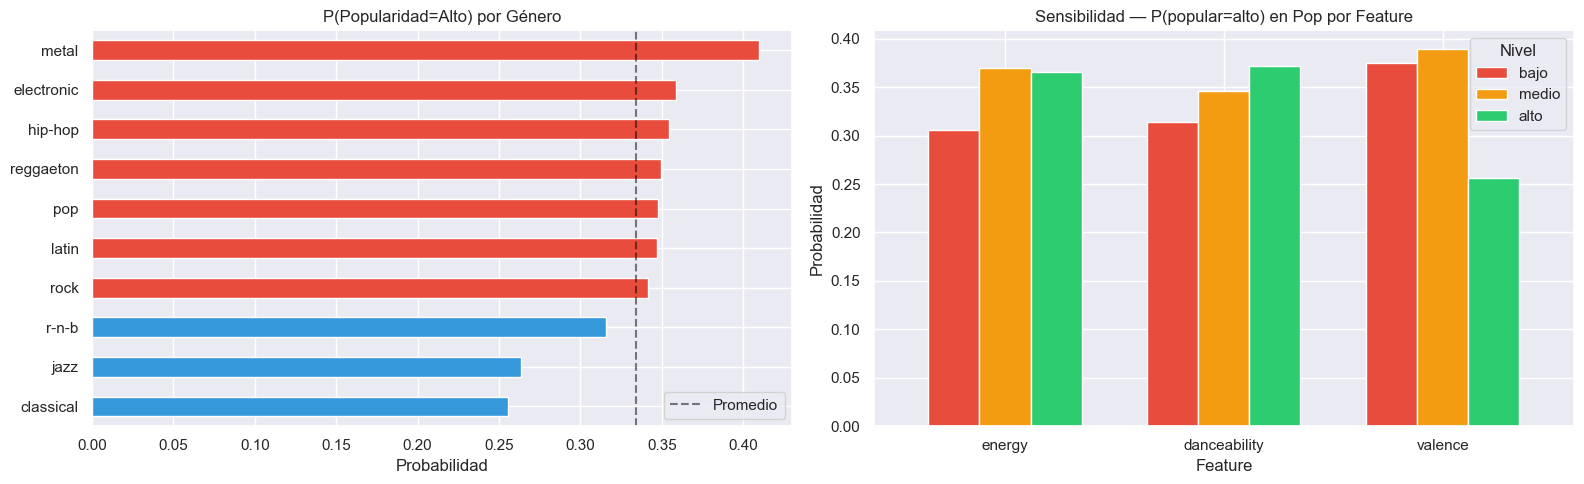

In [12]:
# ── Popularidad inferida por género + Análisis de sensibilidad
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# P(popular=alto) por género
genre_pop = {}
for g in SELECTED_GENRES:
    result = infer.query(['popularity_d'], evidence={'genre': g})
    states = result.state_names['popularity_d']
    genre_pop[g] = dict(zip(states, result.values)).get('alto', 0)

gp = pd.Series(genre_pop).sort_values()
avg = gp.mean()
colors_bar = ['#e74c3c' if v > avg else '#3498db' for v in gp.values]
gp.plot(kind='barh', ax=axes[0], color=colors_bar)
axes[0].axvline(avg, color='black', linestyle='--', alpha=0.5, label='Promedio')
axes[0].set_title('P(Popularidad=Alto) por Género')
axes[0].set_xlabel('Probabilidad')
axes[0].legend()

# Análisis de sensibilidad en pop
sensitivity = {}
for feat in ['energy_d', 'danceability_d', 'valence_d']:
    sensitivity[feat] = {}
    for level in ['bajo', 'medio', 'alto']:
        result = infer.query(['popularity_d'], evidence={'genre': 'pop', feat: level})
        states = result.state_names['popularity_d']
        sensitivity[feat][level] = dict(zip(states, result.values)).get('alto', 0)

sens_df = pd.DataFrame(sensitivity).T
sens_df.plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71'],
             edgecolor='white', width=0.7)
axes[1].set_title('Sensibilidad — P(popular=alto) en Pop por Feature')
axes[1].set_xlabel('Feature'); axes[1].set_ylabel('Probabilidad')
axes[1].set_xticklabels(['energy', 'danceability', 'valence'], rotation=0)
axes[1].legend(title='Nivel')

plt.tight_layout(); plt.show()

## 7. Demo Interactivo — Sistema de Recomendación

Seleccioná géneros → elegí canciones que te gustan → recibí recomendaciones personalizadas.

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ─────────────────────────────────────────────
# PASO 1 — Selección de géneros
# ─────────────────────────────────────────────
genre_selector = widgets.SelectMultiple(
    options=SELECTED_GENRES,
    value=['pop'],
    description='Géneros:',
    style={'description_width': '80px'},
    layout=widgets.Layout(height='180px', width='280px')
)

genre_label = widgets.HTML(
    value="<b>① Selecciona uno o más géneros que te gusten:</b><br><i style='color:gray'>(Ctrl+Click para seleccionar varios)</i>"
)

btn_cargar = widgets.Button(
    description='Cargar canciones →',
    button_style='primary',
    layout=widgets.Layout(width='200px', margin='10px 0')
)

out_songs = widgets.Output()
out_result = widgets.Output()

# ─────────────────────────────────────────────
# Estado compartido
# ─────────────────────────────────────────────
state = {'song_options': [], 'song_checkboxes': []}

# ─────────────────────────────────────────────
# PASO 2 — Selección de canciones
# ─────────────────────────────────────────────
def cargar_canciones(btn):
    with out_songs:
        clear_output(wait=True)
        out_result.clear_output()

        selected_genres = list(genre_selector.value)
        if not selected_genres:
            print('⚠️ Seleccioná al menos un género.')
            return

        # Top canciones populares de esos géneros
        subset = df_disc[df_disc['track_genre'].isin(selected_genres)]
        top_songs = (subset
                     .nlargest(30, 'popularity')
                     .drop_duplicates('track_name')
                     .head(20))

        state['song_options'] = top_songs.to_dict('records')

        header = widgets.HTML(
            value=f"<b>② Elegí canciones que te gusten de: {', '.join(selected_genres)}</b><br>"
                  f"<i style='color:gray'>Seleccioná entre 1 y 5 canciones</i>"
        )

        checkboxes = []
        for row in state['song_options']:
            label = f"🎵 {row['track_name']} — {row['artists']} ({row['track_genre']})"
            cb = widgets.Checkbox(value=False, description=label,
                                  style={'description_width': 'initial'},
                                  layout=widgets.Layout(width='600px'))
            checkboxes.append(cb)

        state['song_checkboxes'] = checkboxes

        btn_recomendar = widgets.Button(
            description='Recomendar',
            button_style='success',
            layout=widgets.Layout(width='200px', margin='12px 0')
        )
        btn_recomendar.on_click(hacer_recomendacion)

        box_songs = widgets.VBox(
            [header] + checkboxes + [btn_recomendar],
            layout=widgets.Layout(padding='10px')
        )
        display(box_songs)

# ─────────────────────────────────────────────
# PASO 3 — Recomendación
# ─────────────────────────────────────────────
def hacer_recomendacion(btn):
    with out_result:
        clear_output(wait=True)

        picked_indices = [i for i, cb in enumerate(state['song_checkboxes']) if cb.value]
        if not picked_indices:
            print('Selecciona al menos una canción.')
            return
        if len(picked_indices) > 5:
            print('Selecciona máximo 5 canciones.')
            return

        picked_songs = [state['song_options'][i] for i in picked_indices]
        picked_df = pd.DataFrame(picked_songs)

        # Perfil del usuario a partir de sus canciones elegidas
        profile = picked_df[['danceability', 'energy', 'valence', 'acousticness']].mean()
        liked_genres = list(genre_selector.value)

        print(f'\nPerfil musical detectado (promedio de tus canciones):')
        for feat, val in profile.items():
            bar = '█' * int(val * 20)
            print(f'  {feat:<16} {val:.2f}  {bar}')

        # Filtrar candidatos con perfil similar
        margin = 0.25
        mask = (
            (df_disc['track_genre'].isin(liked_genres)) &
            (df_disc['energy'].between(profile['energy'] - margin, profile['energy'] + margin)) &
            (df_disc['danceability'].between(profile['danceability'] - margin, profile['danceability'] + margin)) &
            (~df_disc['track_name'].isin(picked_df['track_name']))  # excluir ya elegidas
        )
        candidates = df_disc[mask].copy()

        if candidates.empty:
            candidates = df_disc[df_disc['track_genre'].isin(liked_genres)].copy()

        # Score bayesiano
        def bn_score(row):
            try:
                result = infer.query(
                    ['popularity_d'],
                    evidence={
                        'genre': row['track_genre'],
                        'energy_d': row['energy_d'],
                        'danceability_d': row['danceability_d'],
                        'valence_d': row['valence_d']
                    }
                )
                states = result.state_names['popularity_d']
                vals = result.values
                prob_dict = dict(zip(states, vals))
                return prob_dict.get('alto', 0)
            except:
                return 0

        sample = candidates.sample(min(300, len(candidates)), random_state=42)
        sample['bn_score'] = sample.apply(bn_score, axis=1)
        sample['final_score'] = sample['bn_score'] * 0.6 + sample['popularity'] / 100 * 0.4
        top = sample.nlargest(8, 'final_score').reset_index(drop=True)

        # ── Mostrar resultados ──
        print('\n' + '─'*60)
        print('🎶 CANCIONES RECOMENDADAS PARA VOS')
        print('─'*60)

        display_df = top[['artists', 'track_name', 'track_genre', 'popularity', 'bn_score']].copy()
        display_df.columns = ['Artista', 'Canción', 'Género', 'Popularidad', 'Score BN']
        display_df['Score BN'] = display_df['Score BN'].round(3)
        display_df.index = range(1, len(display_df) + 1)
        display(display_df)

        # ── Gráfico ──
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Barras de score final
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top)))
        axes[0].barh(
            [f"{r['track_name'][:25]}..." if len(r['track_name']) > 25 else r['track_name']
             for _, r in top.iterrows()],
            top['final_score'],
            color=colors
        )
        axes[0].set_xlabel('Score Final (BN + Popularidad)')
        axes[0].set_title('Ranking de Recomendaciones')
        axes[0].invert_yaxis()

        # Radar-style: perfil del usuario vs recomendaciones
        feat_labels = ['danceability', 'energy', 'valence', 'acousticness']
        user_vals = [profile[f] for f in feat_labels]
        rec_vals = [top[f].mean() for f in feat_labels]

        x = np.arange(len(feat_labels))
        w = 0.35
        axes[1].bar(x - w/2, user_vals, w, label='Tu perfil', color='steelblue', alpha=0.8)
        axes[1].bar(x + w/2, rec_vals, w, label='Recomendaciones', color='darkorange', alpha=0.8)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(feat_labels)
        axes[1].set_ylim(0, 1)
        axes[1].set_title('Tu perfil vs Features recomendadas')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

# ─────────────────────────────────────────────
# Montar todo
# ─────────────────────────────────────────────
btn_cargar.on_click(cargar_canciones)

ui = widgets.VBox([
    widgets.HTML(value="<h2>🎵 Sistema de Recomendación Musical</h2>"),
    widgets.HTML(value="<hr>"),
    genre_label,
    genre_selector,
    btn_cargar,
    out_songs,
    out_result
], layout=widgets.Layout(padding='15px'))

display(ui)


## 8. Comparación Final: ML vs Red Bayesiana

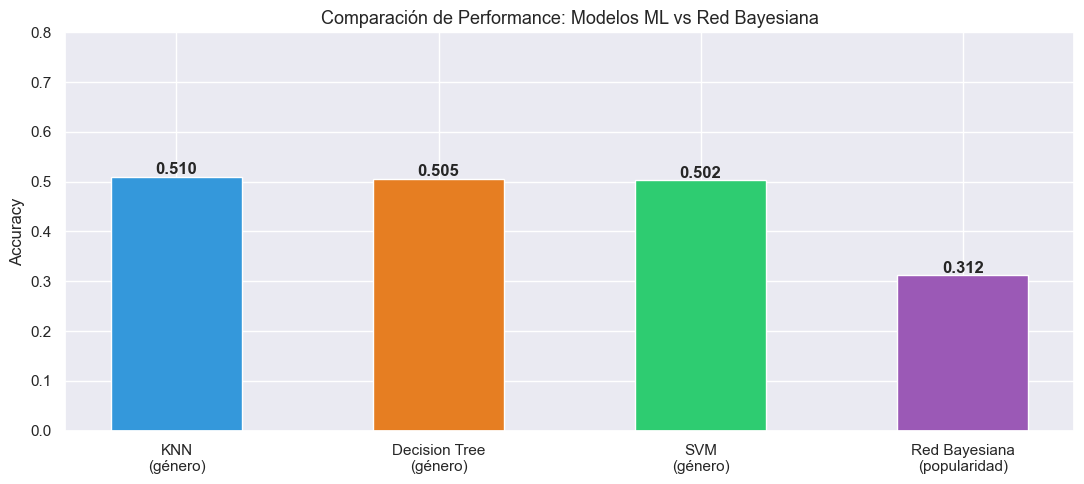


Nota: ML clasifica género (10 clases). BN predice popularidad (3 clases).
Son tareas distintas y complementarias en el sistema de recomendación.


In [15]:
# Evaluar accuracy de la BN en predicción de popularidad
test_sample = df_disc.sample(500, random_state=42)
correct = 0
for _, row in test_sample.iterrows():
    try:
        result = infer.query(['popularity_d'], evidence={
            'genre': row['track_genre'],
            'energy_d': row['energy_d'],
            'danceability_d': row['danceability_d'],
            'valence_d': row['valence_d']
        })
        states = result.state_names['popularity_d']
        pred = states[np.argmax(result.values)]
        if pred == row['popularity_d']: correct += 1
    except: pass

bn_acc = correct / len(test_sample)

# Gráfico comparativo final
modelos = ['KNN\n(género)', 'Decision Tree\n(género)', 'SVM\n(género)', 'Red Bayesiana\n(popularidad)']
accuracies = [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_dt),
              accuracy_score(y_test, y_pred_svm), bn_acc]
colors_f = ['#3498db','#e67e22','#2ecc71','#9b59b6']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(modelos, accuracies, color=colors_f, edgecolor='white', width=0.5)
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0, 0.8)
ax.set_title('Comparación de Performance: Modelos ML vs Red Bayesiana', fontsize=13)
ax.set_ylabel('Accuracy')
plt.tight_layout(); plt.show()

print(f'\nNota: ML clasifica género (10 clases). BN predice popularidad (3 clases).')
print(f'Son tareas distintas y complementarias en el sistema de recomendación.')